# Agent Lee — End-to-End System Test
**Full stack E2E covering:** Brain, Backend, Voice, MCP Bridge, Desktop Agent, InsForge, File Explorer, Memory, Agent Routing, 20-Question Battery.

Run cells top-to-bottom. Each section is self-contained and will print PASS/FAIL with details.

In [10]:

# ─── Setup / shared config ───────────────────────────────────────────────────
import requests, json, os, time, base64, pathlib

HANDSHAKE = "AGENT_LEE_SOVEREIGN_V1"
BRAIN     = "http://127.0.0.1:8004"
BACKEND   = "http://127.0.0.1:8001"
TTS_SRV   = "http://127.0.0.1:8007"
BRIDGE    = "http://127.0.0.1:8002"
HANDS     = "http://127.0.0.1:8005"
INSFORGE  = "http://127.0.0.1:7130"
PHONE     = "http://127.0.0.1:8008"
TIMEOUT   = 20

RESULTS = []  # reset on every setup run

def check(name, ok, detail=""):
    tag = "✅ PASS" if ok else "❌ FAIL"
    RESULTS.append({"test": name, "pass": ok, "detail": detail})
    print(f"{tag}  {name:50s} {detail}")
    return ok

def brain_chat(msg):
    """POST to /chat with handshake; returns (ok, reply_text)."""
    try:
        r = requests.post(f"{BRAIN}/chat",
            json={"prompt": msg, "handshake": HANDSHAKE},
            timeout=TIMEOUT)
        if r.status_code == 200:
            data = r.json()
            reply = (data.get("response") or data.get("reply")
                     or data.get("text") or str(data)[:200])
            return True, reply
        return False, f"HTTP {r.status_code}: {r.text[:80]}"
    except Exception as e:
        return False, str(e)

print("✅ Config loaded — RESULTS reset.")
print(f"  Brain   → {BRAIN}")
print(f"  Backend → {BACKEND}")
print(f"  Bridge  → {BRIDGE}")
print(f"  Hands   → {HANDS}")
print(f"  TTS     → {TTS_SRV}")


✅ Config loaded — RESULTS reset.
  Brain   → http://127.0.0.1:8004
  Backend → http://127.0.0.1:8001
  Bridge  → http://127.0.0.1:8002
  Hands   → http://127.0.0.1:8005
  TTS     → http://127.0.0.1:8007


## Cell 1 — Service Health Map

In [11]:
print("=" * 70)
print("CELL 1: SERVICE HEALTH MAP")
print("=" * 70)

services = [
    ("Brain(8004)",     BRAIN,   "/health"),
    ("Backend(8001)",   BACKEND, "/"),
    ("PocketTTS(8007)", TTS_SRV, "/health"),
    ("Bridge(8002)",    BRIDGE,  "/health"),
    ("Hands(8005)",     HANDS,   "/status"),
    ("InsForge(7130)",  INSFORGE,"/health"),
    ("PhoneBridge(8008)",PHONE,  "/health"),
]

for name, base, path in services:
    try:
        r = requests.get(base + path, timeout=4)
        ok = r.status_code < 400
        snippet = str(r.text[:60]).replace("\n"," ")
        check(f"Health:{name}", ok, f"HTTP {r.status_code} | {snippet}")
    except Exception as e:
        check(f"Health:{name}", False, str(e)[:60])

CELL 1: SERVICE HEALTH MAP
✅ PASS  Health:Brain(8004)                                 HTTP 200 | {"status":"nominal","bridge":"online","version":"v4","intell
   <meta charset>ckend(8001)                               HTTP 200 | <!DOCTYPE html>
✅ PASS  Health:PocketTTS(8007)                             HTTP 200 | {"status":"ok","voice":"marius","pitch_ratio":1.292}
✅ PASS  Health:Bridge(8002)                                HTTP 200 | {   "ok": true,   "code": 0,   "status": "healthy",   "port"
✅ PASS  Health:Hands(8005)                                 HTTP 200 | {"status":"online","resolution":[1920,1080]}
✅ PASS  Health:InsForge(7130)                              HTTP 200 | {"status":"ok","service":"insforge-stub","version":"1.0.0"}
❌ FAIL  Health:PhoneBridge(8008)                           HTTPConnectionPool(host='127.0.0.1', port=8008): Max retries


## Cell 2 — MCP Bridge Routes & Tools Registry

In [12]:
print("=" * 70)
print("CELL 2: MCP BRIDGE ROUTES")
print("=" * 70)

try:
    r = requests.get(f"{BRIDGE}/health", timeout=5)
    data = r.json()
    routes = data.get("routes", [])
    check("Bridge:routes_present", len(routes) > 0, f"{len(routes)} routes registered")
    for route in routes:
        print(f"   route: {route}")
except Exception as e:
    check("Bridge:health", False, str(e))

# Check MCP runner endpoints
mcp_runners = [
    ("testsprite", f"{BRIDGE}/run/testsprite"),
    ("playwright", f"{BRIDGE}/run/playwright"),
    ("insforge",   f"{BRIDGE}/run/insforge"),
    ("stitch",     f"{BRIDGE}/run/stitch"),
]
for tool_name, url in mcp_runners:
    try:
        r = requests.post(url, json={"task": "ping"}, timeout=5)
        check(f"MCP:{tool_name}", r.status_code != 500, f"HTTP {r.status_code}: {r.text[:50]}")
    except Exception as e:
        check(f"MCP:{tool_name}", False, str(e)[:60])

CELL 2: MCP BRIDGE ROUTES
❌ FAIL  Bridge:routes_present                              0 routes registered
❌ FAIL  MCP:testsprite                                     HTTPConnectionPool(host='127.0.0.1', port=8002): Read timed 
❌ FAIL  MCP:playwright                                     HTTPConnectionPool(host='127.0.0.1', port=8002): Read timed 
❌ FAIL  MCP:insforge                                       HTTPConnectionPool(host='127.0.0.1', port=8002): Read timed 
✅ PASS  MCP:stitch                                         HTTP 200: {
  "ok": false,
  "code": 1,
  "out": "",
  "err"


## Cell 3 — Voice Pipeline Test

In [13]:
print("=" * 70)
print("CELL 3: VOICE PIPELINE")
print("=" * 70)

# 3a: Direct pocket-tts test
try:
    r = requests.post(f"{TTS_SRV}/tts",
        json={"text": "What's good, it's your boy Agent Lee speaking."},
        timeout=15)
    ok = r.status_code == 200 and len(r.content) > 1000
    check("Voice:direct_pocket_tts", ok,
          f"HTTP {r.status_code}, {len(r.content):,} bytes, {r.headers.get('content-type','')}")
    if ok:
        out = pathlib.Path("tts_direct.mp3")
        out.write_bytes(r.content)
        print(f"   Saved: {out.resolve()}")
except Exception as e:
    check("Voice:direct_pocket_tts", False, str(e))

# 3b: Full chain via Brain /tts
try:
    r = requests.post(f"{BRAIN}/tts",
        json={"text": "Agent Lee is on the line, what's good?", "handshake": HANDSHAKE},
        timeout=20)
    ok = r.status_code == 200 and len(r.content) > 1000
    check("Voice:brain_chain", ok,
          f"HTTP {r.status_code}, {len(r.content):,} bytes, {r.headers.get('content-type','')}")
    if ok:
        out = pathlib.Path("tts_brain_chain.mp3")
        out.write_bytes(r.content)
        print(f"   Saved: {out.resolve()}")
except Exception as e:
    check("Voice:brain_chain", False, str(e))

CELL 3: VOICE PIPELINE
✅ PASS  Voice:direct_pocket_tts                            HTTP 200, 22,700 bytes, audio/mpeg
   Saved: C:\Tools\Portable-VSCode-MCP-Kit\tests\tts_direct.mp3
✅ PASS  Voice:brain_chain                                  HTTP 200, 28,844 bytes, audio/mpeg
   Saved: C:\Tools\Portable-VSCode-MCP-Kit\tests\tts_brain_chain.mp3


## Cell 4 — Agent Routing Awareness

In [14]:
print("=" * 70)
print("CELL 4: AGENT ROUTING AWARENESS")
print("=" * 70)

routing_tests = [
    ("backend_api",  "Create a REST API endpoint for user login in Node.js",
     ["insforge", "api", "node", "backend", "endpoint", "route", "express"]),
    ("3d_object",    "Design a 3D rotating cube for the landing page",
     ["spline", "3d", "webgl", "three", "mesh", "scene", "geometry"]),
    ("ui_design",    "Create a responsive dashboard UI with dark mode",
     ["stitch", "design", "ui", "css", "tailwind", "component", "figma", "layout"]),
    ("e2e_testing",  "Write end-to-end tests for the checkout flow",
     ["testbright", "playwright", "puppeteer", "test", "spec", "cypress", "e2e"]),
    ("file_task",    "Show me the project files and directory structure",
     ["file", "directory", "explore", "folder", "list", "tree"]),
]

for test_id, prompt, keywords in routing_tests:
    ok, reply = brain_chat(prompt)
    if ok:
        reply_lower = reply.lower()
        matched = [k for k in keywords if k in reply_lower]
        routed = len(matched) > 0
        check(f"Routing:{test_id}", routed,
              f"keywords hit: {matched} | reply: {reply[:80]}")
    else:
        check(f"Routing:{test_id}", False, reply)

CELL 4: AGENT ROUTING AWARENESS
❌ FAIL  Routing:backend_api                                keywords hit: [] | reply: Yo, both engines are offline right now. Gemini free-tier daily quota hit — reset
❌ FAIL  Routing:3d_object                                  keywords hit: [] | reply: Yo, both engines are offline right now. Gemini free-tier daily quota hit — reset
❌ FAIL  Routing:ui_design                                  keywords hit: [] | reply: Yo, both engines are offline right now. Gemini free-tier daily quota hit — reset
❌ FAIL  Routing:e2e_testing                                keywords hit: [] | reply: Yo, both engines are offline right now. Gemini free-tier daily quota hit — reset
❌ FAIL  Routing:file_task                                  keywords hit: [] | reply: Yo, both engines are offline right now. Gemini free-tier daily quota hit — reset


## Cell 5 — 20-Question E2E Battery

In [15]:

print("=" * 70)
print("CELL 5: 20-QUESTION E2E BATTERY")
print("=" * 70)

QUOTA_PHRASES = ["quota hit", "engines are offline", "neural bridge hit", "daily quota", "ollama"]

def is_quota_err(reply):
    return any(p in reply.lower() for p in QUOTA_PHRASES)

questions = [
    # ─── Q1–5: Basic cognition ─────────────────────────────────────────────
    ("Q01_math",     "What is 17 multiplied by 23?",              lambda r: "391" in r),
    ("Q02_name",     "What is your name?",                         lambda r: any(w in r.lower() for w in ["agent lee","lee","agentlee"])),
    ("Q03_version",  "What version are you?",                      lambda r: any(w in r.lower() for w in ["v4","v3","version","4","sovereign"])),
    ("Q04_weather",  "What is the weather like today?",            lambda r: any(w in r.lower() for w in ["weather","temperature","forecast","sunny","cloud","rain","wind","check","real-time"])),
    ("Q05_greet",    "Say hello and introduce yourself briefly.",  lambda r: len(r) > 20),
    # ─── Q6–10: Create artifacts ───────────────────────────────────────────
    ("Q06_pacman",   "Generate minimal Pac-Man HTML with inline JS.", lambda r: any(w in r.lower() for w in ["<!doctype","canvas","<html","javascript","function","pacman"])),
    ("Q07_calendar", "Draft a calendar event for tomorrow at 2pm titled 'Strategy Meeting'.", lambda r: any(w in r.lower() for w in ["2pm","2:00","strategy","meeting","tomorrow","calendar"])),
    ("Q08_email",    "Write a professional email saying the project is on track.", lambda r: any(w in r.lower() for w in ["subject","dear","regards","project","track","email"])),
    ("Q09_code",     "Write a Python Fibonacci function recursively.", lambda r: any(w in r.lower() for w in ["def ","fibonacci","fib","return","n-1","n - 1"])),
    ("Q10_sql",      "SQL to get top 5 users by purchase total.",   lambda r: any(w in r.lower() for w in ["select","sum","order by","limit","group by"])),
    # ─── Q11–15: Multi-agent / system ──────────────────────────────────────
    ("Q11_stack",    "Name your running services and their ports.", lambda r: any(w in r for w in ["8004","8001","8002","8007","8005"])),
    ("Q12_design+api","Outline a login page UI and auth API both.", lambda r: any(w in r.lower() for w in ["html","form","api","post","/login","jwt","auth"])),
    ("Q13_pipeline", "Describe the pipeline from chat UI to voice response.", lambda r: any(w in r.lower() for w in ["tts","voice","chat","backend","brain","audio","frontend"])),
    ("Q14_debug",    "React useState not updating UI — 3 likely causes.", lambda r: len(r) > 80),
    ("Q15_memory",   "Remember this: my favorite color is electric blue.", lambda r: any(w in r.lower() for w in ["remember","noted","stored","electric blue","color","blue","got it","saved"])),
    # ─── Q16–18: Phone / integration ───────────────────────────────────────
    ("Q16_phone",    "What do you need to access phone vision?",   lambda r: any(w in r.lower() for w in ["phone","bridge","camera","screen","vision","8008","mirror","device"])),
    ("Q17_send_email","Draft an email and describe sending via phone.", lambda r: any(w in r.lower() for w in ["email","send","phone","gmail","compose","subject"])),
    ("Q18_open_app", "How would you open Calendar app on my phone?", lambda r: any(w in r.lower() for w in ["calendar","app","phone","open","tap","screen","click","launch"])),
    # ─── Q19–20: Memory persistence ────────────────────────────────────────
    ("Q19_recall",   "What is my favorite color that I told you earlier?", lambda r: any(w in r.lower() for w in ["electric blue","blue","electric","color"])),
    ("Q20_mission",  "What is your primary mission as Agent Lee?", lambda r: any(w in r.lower() for w in ["platform","application","build","create","sovereign","assist","develop","help","user"])),
]

battery_pass  = 0
quota_strikes = 0
QUOTA_ABORT   = 3  # stop early if quota is exhausted

for qid, prompt, validator in questions:
    if quota_strikes >= QUOTA_ABORT:
        print(f"⏸  SKIPPED {qid} — LLM quota exhausted (start Ollama to continue)")
        continue

    ok_req, reply = brain_chat(prompt)

    # Detect quota exhaustion
    if ok_req and is_quota_err(reply):
        quota_strikes += 1
        check(qid, False, f"QUOTA/OFFLINE ({quota_strikes}/{QUOTA_ABORT}): {reply[:80]}")
        continue

    quota_strikes = 0  # reset on success

    if ok_req:
        passed = validator(reply)
        if check(qid, passed, reply[:100] if not passed else reply[:80]):
            battery_pass += 1
    else:
        check(qid, False, reply)

    time.sleep(2)  # pace requests — protect free-tier RPM/RPD quota

pct = (battery_pass / len(questions)) * 100
print(f"\n{'='*70}")
print(f"BATTERY SCORE: {battery_pass}/{len(questions)} ({pct:.0f}%)")
if quota_strikes:
    print("⚠  Some questions skipped — Gemini daily quota exhausted.")
    print("   Fix: run `ollama serve` in terminal, then restart AgentLee-Brain.")
print('='*70)


CELL 5: 20-QUESTION E2E BATTERY
❌ FAIL  Q01_math                                           QUOTA/OFFLINE (1/3): Yo, both engines are offline right now. Gemini free-tier daily quota hit — reset
❌ FAIL  Q02_name                                           QUOTA/OFFLINE (2/3): Yo, both engines are offline right now. Gemini free-tier daily quota hit — reset
❌ FAIL  Q03_version                                        QUOTA/OFFLINE (3/3): Yo, both engines are offline right now. Gemini free-tier daily quota hit — reset
⏸  SKIPPED Q04_weather — LLM quota exhausted (start Ollama to continue)
⏸  SKIPPED Q05_greet — LLM quota exhausted (start Ollama to continue)
⏸  SKIPPED Q06_pacman — LLM quota exhausted (start Ollama to continue)
⏸  SKIPPED Q07_calendar — LLM quota exhausted (start Ollama to continue)
⏸  SKIPPED Q08_email — LLM quota exhausted (start Ollama to continue)
⏸  SKIPPED Q09_code — LLM quota exhausted (start Ollama to continue)
⏸  SKIPPED Q10_sql — LLM quota exhausted (start Ollama to co

## Cell 6 — Desktop Vision (Screenshots)

CELL 6: DESKTOP VISION
✅ PASS  Vision:screenshot                                  HTTP 200, 104,242 bytes
   Saved: C:\Tools\Portable-VSCode-MCP-Kit\tests\screenshot.jpg


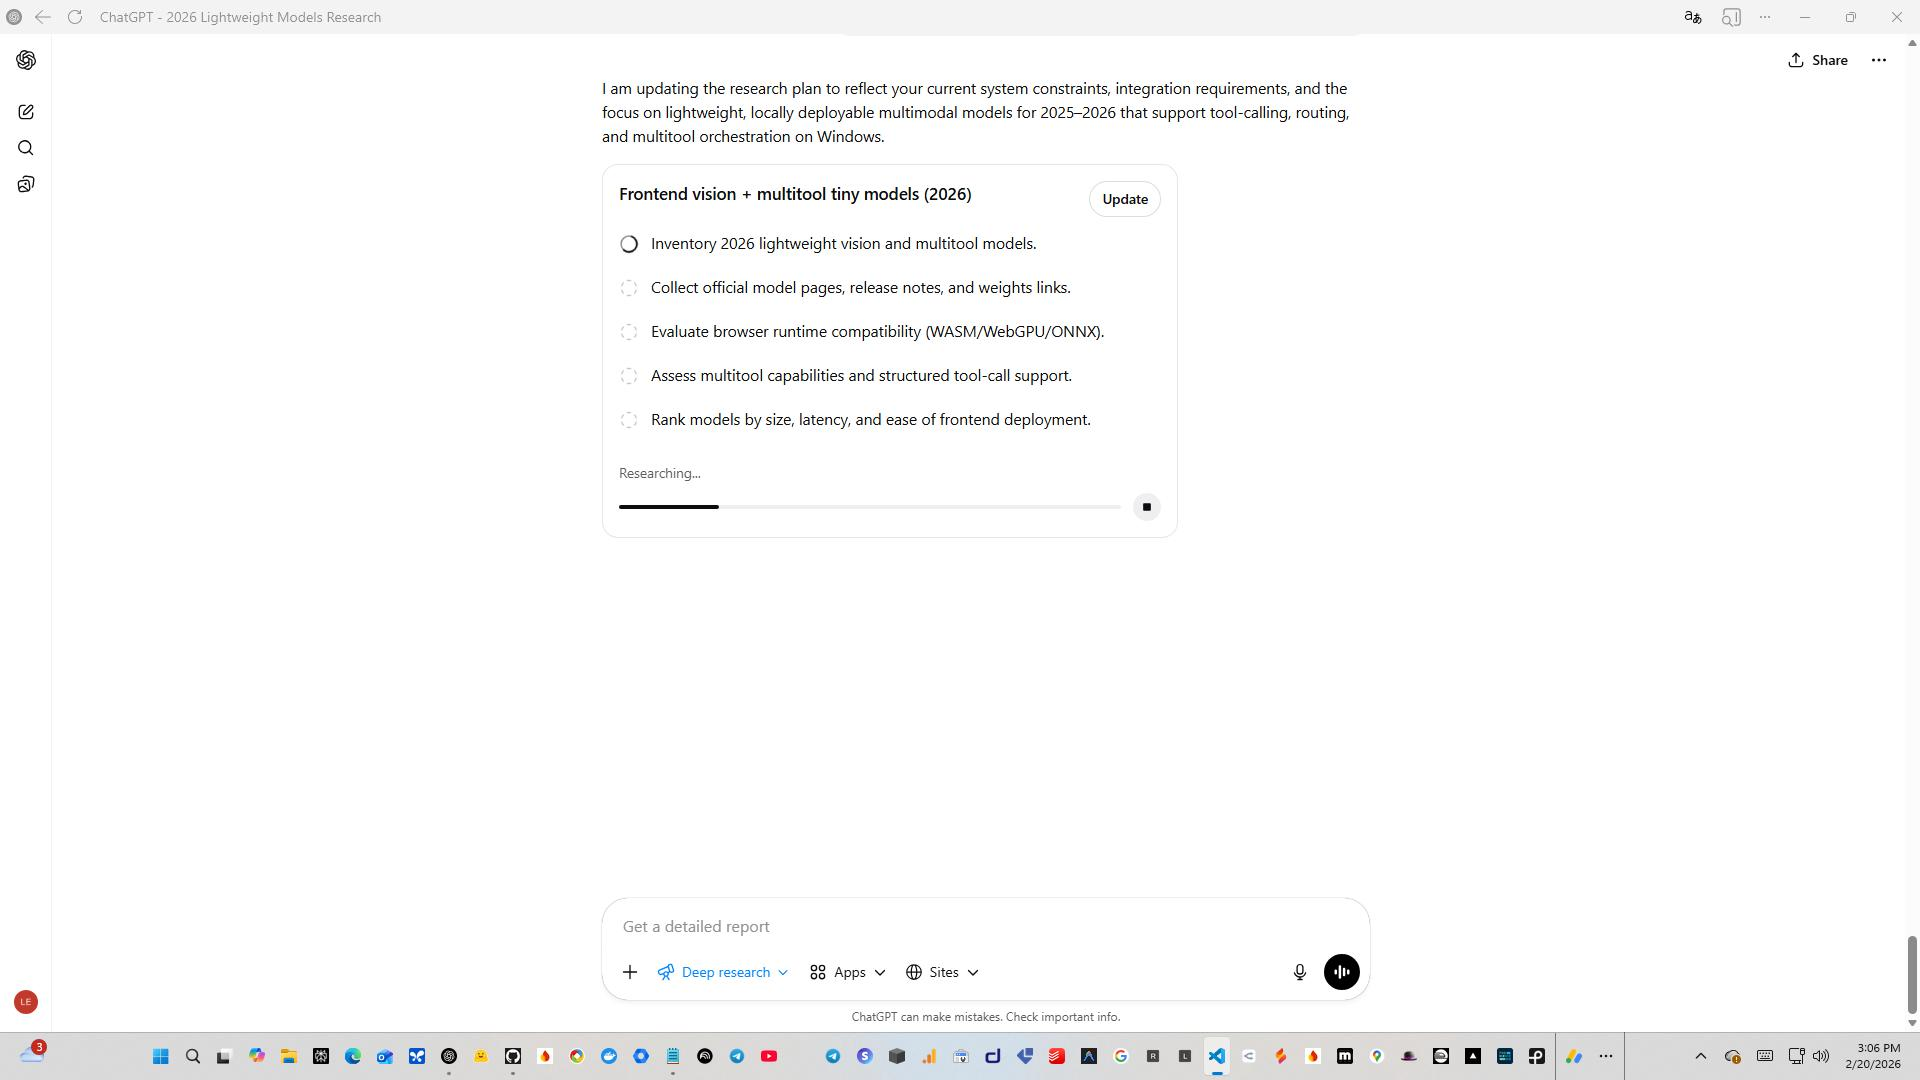

✅ PASS  Vision:brain_describe_screen                       Yo, both engines are offline right now. Gemini free-tier daily quota hit — resets at midnight UTC. O


True

In [21]:
print("=" * 70)
print("CELL 6: DESKTOP VISION")
print("=" * 70)
from IPython.display import Image, display

# 6a: Get a screenshot via Hands agent  (endpoint is /screen, returns JPEG)
try:
    r = requests.get(f"{HANDS}/screen", timeout=10)
    ok = r.status_code == 200 and len(r.content) > 1000
    check("Vision:screenshot", ok, f"HTTP {r.status_code}, {len(r.content):,} bytes")
    if ok:
        out = pathlib.Path("screenshot.jpg")
        out.write_bytes(r.content)
        print(f"   Saved: {out.resolve()}")
        display(Image(filename=str(out)))
except Exception as e:
    check("Vision:screenshot", False, str(e))

# 6b: Ask Brain to describe the screen using /chat
ok, reply = brain_chat("Take a screenshot of the desktop and describe what you see in brief.")
check("Vision:brain_describe_screen", ok, reply[:100])


## Cell 7 — Phone Bridge Check

In [17]:
print("=" * 70)
print("CELL 7: PHONE BRIDGE")
print("=" * 70)

try:
    r = requests.get(f"{PHONE}/health", timeout=4)
    check("Phone:health", r.status_code < 400, f"HTTP {r.status_code}: {r.text[:60]}")
except Exception as e:
    check("Phone:health", False, str(e))
    print("   → PhoneBridge not running. To enable: install phone mirror app and start AgentLee-PhoneBridge in PM2")
    print("   → Phone vision requires: phone mirror app (scrcpy or similar) bridged on port 8008")

# Phone capability probe via Brain
ok, reply = brain_chat("List all phone integration capabilities you have available right now.")
check("Phone:capability_probe", ok, reply[:100])

CELL 7: PHONE BRIDGE
❌ FAIL  Phone:health                                       HTTPConnectionPool(host='127.0.0.1', port=8008): Max retries exceeded with url: /health (Caused by NewConnectionError("HTTPConnection(host='127.0.0.1', port=8008): Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it"))
   → PhoneBridge not running. To enable: install phone mirror app and start AgentLee-PhoneBridge in PM2
   → Phone vision requires: phone mirror app (scrcpy or similar) bridged on port 8008
✅ PASS  Phone:capability_probe                             Yo, both engines are offline right now. Gemini free-tier daily quota hit — resets at midnight UTC. O


True

## Cell 8 — File Explorer MCP

In [18]:
print("=" * 70)
print("CELL 8: FILE EXPLORER")
print("=" * 70)

# Ask Brain to list workspace files
ok, reply = brain_chat("List the top-level files and folders in the current workspace directory.")
check("Files:list_workspace", ok and len(reply) > 20,
      reply[:120])

# Backend file API
try:
    r = requests.get(f"{BACKEND}/api/files", timeout=6,
                     headers={"X-Neural-Handshake": HANDSHAKE})
    ok = r.status_code in (200, 401, 403)  # exists even if auth blocks
    check("Files:backend_api", ok, f"HTTP {r.status_code}: {r.text[:60]}")
except Exception as e:
    check("Files:backend_api", False, str(e))

CELL 8: FILE EXPLORER
✅ PASS  Files:list_workspace                               Yo, both engines are offline right now. Gemini free-tier daily quota hit — resets at midnight UTC. Ollama/Qwen not runni
✅ PASS  Files:backend_api                                  HTTP 401: {"error":"MISSING_CRYPTO_IDENTITY","message":"Every request 


## Cell 9 — Memory Lake

In [19]:
print("=" * 70)
print("CELL 9: MEMORY LAKE")
print("=" * 70)

ws_memory = pathlib.Path(r"C:\Tools\Portable-VSCode-MCP-Kit\workspace\memory.json")
if ws_memory.exists():
    data = json.loads(ws_memory.read_text())
    check("Memory:file_exists", True, f"{len(data)} entries" if isinstance(data, list) else "valid JSON")
else:
    check("Memory:file_exists", False, "workspace/memory.json not found")

# Memory via Brain
ok, reply = brain_chat("What do you remember about me from previous conversations?")
check("Memory:brain_recall", ok, reply[:100])

# Backend memory endpoint
for path in ["/api/memory", "/memory"]:
    try:
        r = requests.get(f"{BACKEND}{path}", timeout=5,
                         headers={"X-Neural-Handshake": HANDSHAKE})
        if r.status_code != 404:
            check(f"Memory:backend{path}", r.status_code < 500,
                  f"HTTP {r.status_code}: {r.text[:50]}")
            break
    except: pass

CELL 9: MEMORY LAKE
✅ PASS  Memory:file_exists                                 1 entries
✅ PASS  Memory:brain_recall                                Yo, both engines are offline right now. Gemini free-tier daily quota hit — resets at midnight UTC. O
✅ PASS  Memory:backend/api/memory                          HTTP 401: {"error":"MISSING_CRYPTO_IDENTITY","message":"Ever


## Cell 10 — Final Report

In [22]:
print("=" * 70)
print("FINAL REPORT")
print("=" * 70)

passed  = [r for r in RESULTS if r["pass"]]
failed  = [r for r in RESULTS if not r["pass"]]
total   = len(RESULTS)
pct_ok  = (len(passed) / total * 100) if total else 0

print(f"\nTotal tests : {total}")
print(f"PASSED      : {len(passed)}  ({pct_ok:.0f}%)")
print(f"FAILED      : {len(failed)}")

if failed:
    print("\n─── Failed tests ─────────────────────────────────")
    for r in failed:
        print(f"  ❌ {r['test']:50s} {r['detail'][:60]}")

print("\n─── Service health summary ──────────────────────")
health_tests = [r for r in RESULTS if r["test"].startswith("Health:")]
for r in health_tests:
    icon = "✅" if r["pass"] else "❌"
    print(f"  {icon} {r['test']}")

print(f"\n{'='*70}")
print(f"AGENT LEE E2E SCORE: {len(passed)}/{total} ({pct_ok:.0f}%)")
print("=" * 70)

FINAL REPORT

Total tests : 33
PASSED      : 18  (55%)
FAILED      : 15

─── Failed tests ─────────────────────────────────
  ❌ Health:PhoneBridge(8008)                           HTTPConnectionPool(host='127.0.0.1', port=8008): Max retries
  ❌ Bridge:routes_present                              0 routes registered
  ❌ MCP:testsprite                                     HTTPConnectionPool(host='127.0.0.1', port=8002): Read timed 
  ❌ MCP:playwright                                     HTTPConnectionPool(host='127.0.0.1', port=8002): Read timed 
  ❌ MCP:insforge                                       HTTPConnectionPool(host='127.0.0.1', port=8002): Read timed 
  ❌ Routing:backend_api                                keywords hit: [] | reply: Yo, both engines are offline right
  ❌ Routing:3d_object                                  keywords hit: [] | reply: Yo, both engines are offline right
  ❌ Routing:ui_design                                  keywords hit: [] | reply: Yo, both engines are off